In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
# Install unrar to handle .rar files
!apt-get install unrar

# Extract the .rar file
!unrar x /content/drive/MyDrive/Colab\ Notebooks/Processed\ data/final_processed_data.rar /content/final_processed_data



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar

No files to extract


In [11]:
import os
os.listdir("/content/drive/MyDrive/Colab Notebooks/Processed data")


['final_processed_data.rar', 'photos.json']

In [12]:
!unrar l "/content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar"


Streaming output truncated to the last 5000 lines.
    ..A....     19413  2025-05-28 02:21  final_processed_data/train/outside/AodVccIykwJUd4a5ebofNQ.jpg
    ..A....     27557  2025-05-28 02:23  final_processed_data/train/outside/aOfnK-6_B99KUtM3m0MdLQ.jpg
    ..A....     14144  2025-05-28 02:25  final_processed_data/train/outside/aOgrimBG9yTPjhVvvL9Tow.jpg
    ..A....     23816  2025-05-28 02:30  final_processed_data/train/outside/AOoALJvONwjiTH_3rWjP-w.jpg
    ..A....     24773  2025-05-28 02:31  final_processed_data/train/outside/AOpLEXZO8AR3itilGLvblw.jpg
    ..A....     21550  2025-05-28 02:29  final_processed_data/train/outside/aoSsaGVkCS6yL4PRZ9BSdQ.jpg
    ..A....     19318  2025-05-28 02:33  final_processed_data/train/outside/aoY0E9yigDOVsQI5T9T-kg.jpg
    ..A....     23132  2025-05-28 02:23  final_processed_data/train/outside/aOYOa5VijKGh_IIBsmQkiA.jpg
    ..A....     27767  2025-05-28 02:30  final_processed_data/train/outside/ap1FQtpFhrHFTKsh6mQQRA.jpg
    ..A....     21831 

In [13]:
!unrar x "/content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar"


Streaming output truncated to the last 5000 lines.
Extracting  final_processed_data/train/outside/Amnj1WgWAZZ_GTCKw6SlaQ.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AmOYmlMkZuPMMhs6OiEg3w.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AMs-eCVwDKmJE6iBK6js0w.jpg      89%  OK 
Extracting  final_processed_data/train/outside/amvOLbJcr-7PcD4GrnOCQg.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AmwHg9k03XXBUkFFPmqF-g.jpg      89%  OK 
Extracting  final_processed_data/train/outside/An4cR5bvcDrnLaqhSUtA-A.jpg      89%  OK 
Extracting  final_processed_data/train/outside/aN7f0NoB2ea5TJOOim2Jhg.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AnAK_o366JeIhhwQ_OnRNQ.jpg      89%  OK 
Extracting  final_processed_data/train/outside/ANB9fjfnOdRm97uwxpF3JA.jpg      89%  OK 
Extracting  final_processed_data/train/outside/Anbn64bt5yRL7eKJUnaJoQ.jpg   

In [14]:
import os

# Check folder structure
os.listdir("/content/final_processed_data")


['train',
 'menu',
 'food',
 'test',
 'inside',
 'processing_log.json',
 'val',
 'metadata',
 'drink',
 'outside',
 'split_info.json']

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    '/content/final_processed_data/train',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    '/content/final_processed_data/val',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical'
)

test_gen = datagen.flow_from_directory(
    '/content/final_processed_data/test',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 36181 images belonging to 5 classes.
Found 4452 images belonging to 5 classes.
Found 4488 images belonging to 5 classes.


# Build the CNN Architecture

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Create the CNN model
cnn_model = Sequential()

# Convolution + Pooling Layer 1
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 2
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 3
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(5, activation='softmax'))  # 5 classes

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


# Train the Model

In [30]:
# Train the CNN model
history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)


Epoch 1/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1200s 530ms/step - accuracy: 0.8215 - loss: 0.5222 - val_accuracy: 0.8464 - val_loss: 0.4484
Epoch 2/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1191s 526ms/step - accuracy: 0.8351 - loss: 0.4754 - val_accuracy: 0.8553 - val_loss: 0.4197
Epoch 3/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1181s 522ms/step - accuracy: 0.8516 - loss: 0.4368 - val_accuracy: 0.8621 - val_loss: 0.4085
Epoch 4/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1184s 524ms/step - accuracy: 0.8589 - loss: 0.4133 - val_accuracy: 0.8614 - val_loss: 0.3959
Epoch 5/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1182s 523ms/step - accuracy: 0.8711 - loss: 0.3693 - val_accuracy: 0.8610 - val_loss: 0.4049


# Evaluate with Confusion Matrix

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step


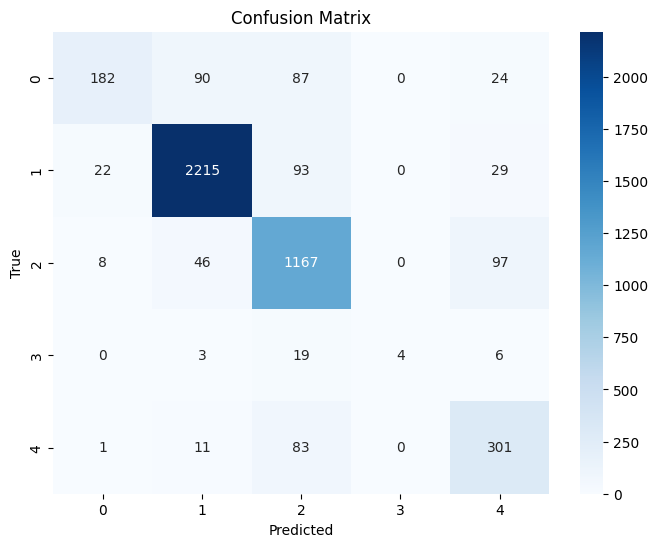

              precision    recall  f1-score   support

       drink       0.85      0.48      0.61       383
        food       0.94      0.94      0.94      2359
      inside       0.81      0.89      0.84      1318
        menu       1.00      0.12      0.22        32
     outside       0.66      0.76      0.71       396

    accuracy                           0.86      4488
   macro avg       0.85      0.64      0.66      4488
weighted avg       0.87      0.86      0.86      4488



In [32]:
# Get predictions
Y_pred_probs = cnn_model.predict(test_gen)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print(classification_report(Y_true, Y_pred, target_names=test_gen.class_indices.keys()))

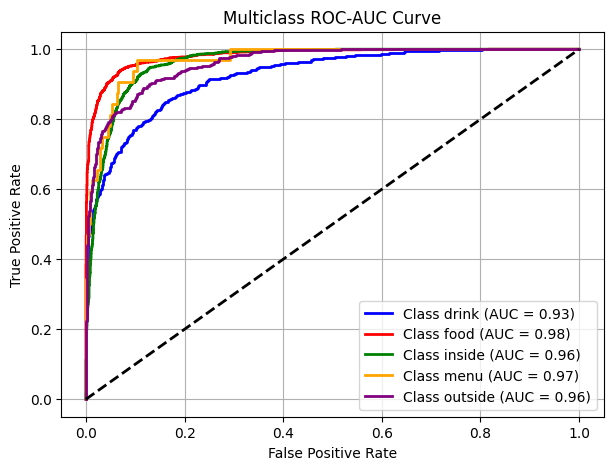

In [37]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

n_classes = 5
Y_true_bin = label_binarize(Y_true, classes=[0, 1, 2, 3, 4])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_true_bin[:, i], Y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(7, 5))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
class_names = list(test_gen.class_indices.keys())

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC-AUC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [34]:
loss, acc = cnn_model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.4f}")


281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.7934 - loss: 0.6463
Test Accuracy: 0.8621
